OUTLIERS BASE LEADS REGISRO

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('Basedeleads_registroleads.csv')
data.head()

,Asesor,Leads_feb24,Leads_mar24,Leads_abr24,Leads_may24,Leads_jun24,Leads_jul24,Leads_ago24,Leads_sep24,Leads_oct24,...,Ventas_sep24,Ventas_oct24,Ventas_nov24,Ventas_dic24,Ventas_ene25,Ventas_feb25,Ventas_mar25,Ventas_abr25,Ventas_may25,Ventas_jun25
0,ABIGAIL,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ALAN GONZALES,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,2.0,4.0,1.0,2.0,1.0,1.0,0.0
2,ALICIA LEDESMA,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AURELIO FELIPE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,...,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,2.0
4,CARLOS ALBERTO NIETO,0.0,0.0,0.0,2.0,0.0,0.0,2.0,8.0,4.0,...,2.0,0.0,3.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 33 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Asesor        40 non-null     str    
 1   Leads_feb24   40 non-null     float64
 2   Leads_mar24   40 non-null     float64
 3   Leads_abr24   40 non-null     float64
 4   Leads_may24   40 non-null     float64
 5   Leads_jun24   40 non-null     float64
 6   Leads_jul24   40 non-null     float64
 7   Leads_ago24   40 non-null     float64
 8   Leads_sep24   40 non-null     float64
 9   Leads_oct24   40 non-null     float64
 10  Leads_nov24   40 non-null     float64
 11  Leads_dic24   40 non-null     float64
 12  Leads_ene25   40 non-null     float64
 13  Leads_feb25   40 non-null     float64
 14  Leads_mar25   40 non-null     float64
 15  Leads_abr25   40 non-null     float64
 16  Ventas_feb24  40 non-null     float64
 17  Ventas_mar24  40 non-null     float64
 18  Ventas_abr24  40 non-null     float64
 19  

In [4]:
valores_nulos = data.isnull().sum()
valores_nulos

Asesor          0
Leads_feb24     0
Leads_mar24     0
Leads_abr24     0
Leads_may24     0
Leads_jun24     0
Leads_jul24     0
Leads_ago24     0
Leads_sep24     0
Leads_oct24     0
Leads_nov24     0
Leads_dic24     0
Leads_ene25     0
Leads_feb25     0
Leads_mar25     0
Leads_abr25     0
Ventas_feb24    0
Ventas_mar24    0
Ventas_abr24    0
Ventas_may24    0
Ventas_jun24    0
Ventas_jul24    0
Ventas_ago24    0
Ventas_sep24    0
Ventas_oct24    0
Ventas_nov24    0
Ventas_dic24    0
Ventas_ene25    0
Ventas_feb25    0
Ventas_mar25    0
Ventas_abr25    0
Ventas_may25    0
Ventas_jun25    0
dtype: int64

In [6]:
#Creamos 2 dataframes para poder procesar los outliers
columnas_identificadoras = ['Asesor']

cualitativas = data[columnas_identificadoras]
cuantitativas = data.drop(columns=columnas_identificadoras)

cuantitativas.head()

,Leads_feb24,Leads_mar24,Leads_abr24,Leads_may24,Leads_jun24,Leads_jul24,Leads_ago24,Leads_sep24,Leads_oct24,Leads_nov24,...,Ventas_sep24,Ventas_oct24,Ventas_nov24,Ventas_dic24,Ventas_ene25,Ventas_feb25,Ventas_mar25,Ventas_abr25,Ventas_may25,Ventas_jun25
0,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,2.0,4.0,1.0,2.0,1.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,0.0,...,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,2.0
4,0.0,0.0,0.0,2.0,0.0,0.0,2.0,8.0,4.0,10.0,...,2.0,0.0,3.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0


<Figure size 1600x900 with 0 Axes>

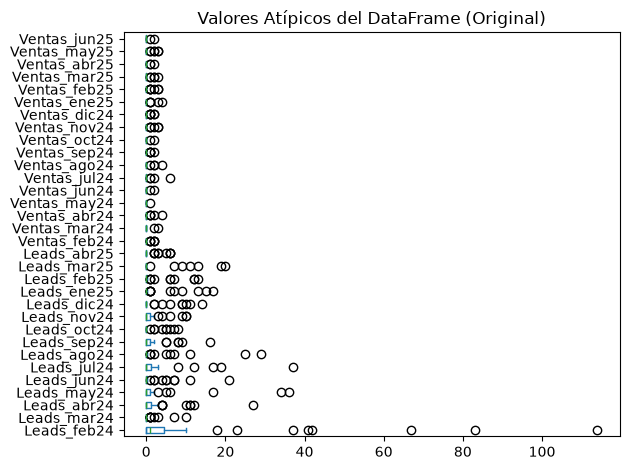

In [16]:
fig = plt.figure(figsize=(16, 9))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del DataFrame (Original)")
plt.tight_layout()
plt.show()

In [ ]:

# MÉTODO IQR con factor 3 (sin opción de percentiles)
# Decidí usar el metodo intercuartil porque me parece estadisticamente mas util
# pero modifique al usar un factor 3 en lugar de 1.5 para ser más tolerante con valores altos.
factor = 3
percentile25 = cuantitativas.quantile(0.25)
percentile75 = cuantitativas.quantile(0.75)
iqr = percentile75 - percentile25
Limite_Superior_iqr = percentile75 + factor * iqr
Limite_Inferior_iqr = percentile25 - factor * iqr

print("\n--- Usando 3·IQR (factor=3) ---")
print("Limite superior permitido:\n", Limite_Superior_iqr)
print("\nLimite inferior permitido:\n", Limite_Inferior_iqr)



--- Usando 3·IQR (factor=3) ---
Limite superior permitido:
 Leads_feb24     18.0
Leads_mar24      0.0
Leads_abr24      5.0
Leads_may24      4.0
Leads_jun24      1.0
Leads_jul24      5.0
Leads_ago24      1.0
Leads_sep24      4.0
Leads_oct24      0.0
Leads_nov24      4.0
Leads_dic24      0.0
Leads_ene25      1.0
Leads_feb25      1.0
Leads_mar25      0.0
Leads_abr25      0.0
Ventas_feb24     0.0
Ventas_mar24     0.0
Ventas_abr24     0.0
Ventas_may24     0.0
Ventas_jun24     0.0
Ventas_jul24     0.0
Ventas_ago24     0.0
Ventas_sep24     0.0
Ventas_oct24     0.0
Ventas_nov24     0.0
Ventas_dic24     0.0
Ventas_ene25     0.0
Ventas_feb25     0.0
Ventas_mar25     0.0
Ventas_abr25     0.0
Ventas_may25     0.0
Ventas_jun25     0.0
dtype: float64

Limite inferior permitido:
 Leads_feb24    -13.50
Leads_mar24      0.00
Leads_abr24     -3.75
Leads_may24     -3.00
Leads_jun24     -0.75
Leads_jul24     -3.75
Leads_ago24     -0.75
Leads_sep24     -3.00
Leads_oct24      0.00
Leads_nov24     -3.00
Lea

In [18]:
data_clean_iqr = data_iqr.copy()
data_clean_iqr = data_clean_iqr.fillna(round(data_iqr.median(), 2))
valores_nulos = data_clean_iqr.isnull().sum()
print("Nulos tras reemplazo (IQR):\n", valores_nulos)

Nulos tras reemplazo (IQR):
 Leads_feb24     0
Leads_mar24     0
Leads_abr24     0
Leads_may24     0
Leads_jun24     0
Leads_jul24     0
Leads_ago24     0
Leads_sep24     0
Leads_oct24     0
Leads_nov24     0
Leads_dic24     0
Leads_ene25     0
Leads_feb25     0
Leads_mar25     0
Leads_abr25     0
Ventas_feb24    0
Ventas_mar24    0
Ventas_abr24    0
Ventas_may24    0
Ventas_jun24    0
Ventas_jul24    0
Ventas_ago24    0
Ventas_sep24    0
Ventas_oct24    0
Ventas_nov24    0
Ventas_dic24    0
Ventas_ene25    0
Ventas_feb25    0
Ventas_mar25    0
Ventas_abr25    0
Ventas_may25    0
Ventas_jun25    0
dtype: int64


<Figure size 1600x900 with 0 Axes>

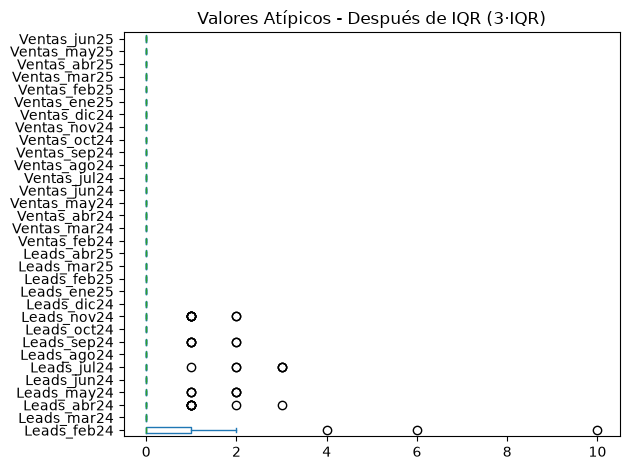

In [19]:
fig = plt.figure(figsize=(16, 9))
data_clean_iqr.plot(kind='box', vert=False)
plt.title("Valores Atípicos - Después de IQR (3·IQR)")
plt.tight_layout()
plt.show()

In [20]:
Datos_limpios = pd.concat([cualitativas, data_clean_iqr], axis=1)
Datos_limpios.head()
valores_nulos = Datos_limpios.isnull().sum()
print("Nulos finales:\n", valores_nulos)

Nulos finales:
 Asesor          0
Leads_feb24     0
Leads_mar24     0
Leads_abr24     0
Leads_may24     0
Leads_jun24     0
Leads_jul24     0
Leads_ago24     0
Leads_sep24     0
Leads_oct24     0
Leads_nov24     0
Leads_dic24     0
Leads_ene25     0
Leads_feb25     0
Leads_mar25     0
Leads_abr25     0
Ventas_feb24    0
Ventas_mar24    0
Ventas_abr24    0
Ventas_may24    0
Ventas_jun24    0
Ventas_jul24    0
Ventas_ago24    0
Ventas_sep24    0
Ventas_oct24    0
Ventas_nov24    0
Ventas_dic24    0
Ventas_ene25    0
Ventas_feb25    0
Ventas_mar25    0
Ventas_abr25    0
Ventas_may25    0
Ventas_jun25    0
dtype: int64


In [22]:
Datos_limpios.to_csv("Basedeleads_registroleads_sin_outliers.csv", index=False)

OUTLIERS BASE LEADS ANÁLISIS DE DESEMPEÑO

In [23]:
Datos_limpios.to_csv("Basedeleads_registroleads_sin_outliers.csv", index=False)

In [25]:
columnas_identificadoras = ['Asesor']
cualitativas = data1[columnas_identificadoras]
cuantitativas = data1.drop(columns=columnas_identificadoras)
cuantitativas.head()

,Leads_feb24,Leads_mar24,Leads_abr24,Leads_may24,Leads_jun24,Leads_jul24,Leads_ago24,Leads_sep24,Leads_oct24,Leads_nov24,...,Ventas_sep24,Ventas_oct24,Ventas_nov24,Ventas_dic24,Ventas_ene25,Ventas_feb25,Ventas_mar25,Ventas_abr25,Ventas_may25,Ventas_jun25
0,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,2.0,4.0,1.0,2.0,1.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,0.0,...,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,2.0
4,0.0,0.0,0.0,2.0,0.0,0.0,2.0,8.0,4.0,10.0,...,2.0,0.0,3.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0


<Figure size 1600x900 with 0 Axes>

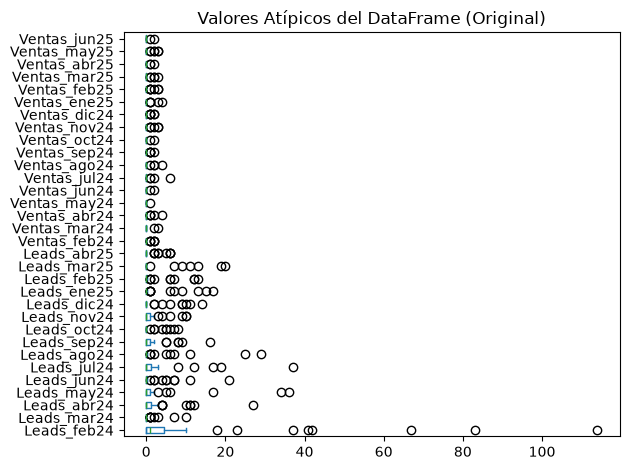

In [26]:
fig = plt.figure(figsize=(16, 9))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del DataFrame (Original)")
plt.tight_layout()
plt.show()

In [ ]:
#Desviación Estándar (solo para prácticar, pero también lo veo útil en este caso porque no se acerca tanto a 
#la media como el método intercuartílico)
y = cuantitativas
Limite_Superior = y.mean() + 3*y.std()
Limite_Inferior = y.mean() - 3*y.std()
print("Limite superior permitido:\n", Limite_Superior)
print("\nLimite inferior permitido:\n", Limite_Inferior)

Limite superior permitido:
 Leads_feb24     87.351380
Leads_mar24      6.534411
Leads_abr24     17.995807
Leads_may24     26.881849
Leads_jun24     13.676572
Leads_jul24     24.033344
Leads_ago24     20.869597
Leads_sep24     11.551343
Leads_oct24      7.516252
Leads_nov24      9.460038
Leads_dic24     12.700582
Leads_ene25     14.727354
Leads_feb25     12.180172
Leads_mar25     17.357283
Leads_abr25      6.402031
Ventas_feb24     1.955385
Ventas_mar24     1.814902
Ventas_abr24     2.425087
Ventas_may24     0.499342
Ventas_jun24     1.124725
Ventas_jul24     3.269170
Ventas_ago24     2.527591
Ventas_sep24     1.430024
Ventas_oct24     1.124725
Ventas_nov24     2.526922
Ventas_dic24     1.749193
Ventas_ene25     2.675823
Ventas_feb25     2.573594
Ventas_mar25     2.204219
Ventas_abr25     1.236797
Ventas_may25     2.672924
Ventas_jun25     1.124725
dtype: float64

Limite inferior permitido:
 Leads_feb24    -64.401380
Leads_mar24     -5.184411
Leads_abr24    -13.245807
Leads_may24    -21

In [28]:
data_std = cuantitativas[(y <= Limite_Superior) & (y >= Limite_Inferior)]
valores_nulos = data_std.isnull().sum()
print("Nulos tras desviación estándar:\n", valores_nulos)


Nulos tras desviación estándar:
 Leads_feb24     1
Leads_mar24     2
Leads_abr24     1
Leads_may24     2
Leads_jun24     1
Leads_jul24     1
Leads_ago24     2
Leads_sep24     1
Leads_oct24     1
Leads_nov24     2
Leads_dic24     1
Leads_ene25     2
Leads_feb25     1
Leads_mar25     2
Leads_abr25     0
Ventas_feb24    3
Ventas_mar24    2
Ventas_abr24    1
Ventas_may24    1
Ventas_jun24    1
Ventas_jul24    1
Ventas_ago24    1
Ventas_sep24    1
Ventas_oct24    1
Ventas_nov24    2
Ventas_dic24    2
Ventas_ene25    2
Ventas_feb25    2
Ventas_mar25    1
Ventas_abr25    1
Ventas_may25    2
Ventas_jun25    1
dtype: int64


In [29]:
data_clean_std = data_std.copy()
data_clean_std = data_clean_std.fillna(round(data_std.mean(), 2))
valores_nulos = data_clean_std.isnull().sum()
print("Nulos tras reemplazo (std):\n", valores_nulos)

Nulos tras reemplazo (std):
 Leads_feb24     0
Leads_mar24     0
Leads_abr24     0
Leads_may24     0
Leads_jun24     0
Leads_jul24     0
Leads_ago24     0
Leads_sep24     0
Leads_oct24     0
Leads_nov24     0
Leads_dic24     0
Leads_ene25     0
Leads_feb25     0
Leads_mar25     0
Leads_abr25     0
Ventas_feb24    0
Ventas_mar24    0
Ventas_abr24    0
Ventas_may24    0
Ventas_jun24    0
Ventas_jul24    0
Ventas_ago24    0
Ventas_sep24    0
Ventas_oct24    0
Ventas_nov24    0
Ventas_dic24    0
Ventas_ene25    0
Ventas_feb25    0
Ventas_mar25    0
Ventas_abr25    0
Ventas_may25    0
Ventas_jun25    0
dtype: int64


<Figure size 1600x900 with 0 Axes>

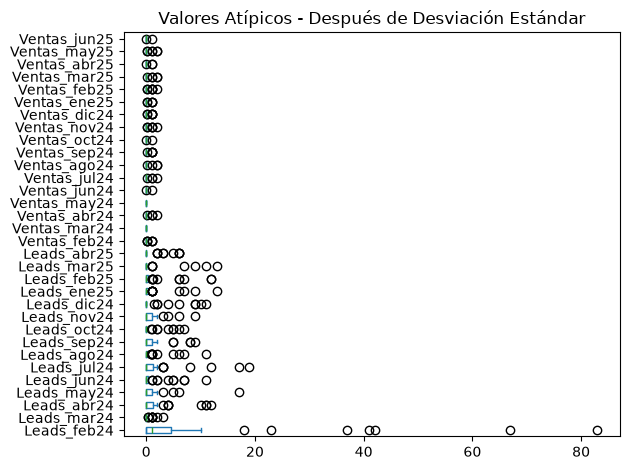

In [30]:
fig = plt.figure(figsize=(16, 9))
data_clean_std.plot(kind='box', vert=False)
plt.title("Valores Atípicos - Después de Desviación Estándar")
plt.tight_layout()
plt.show()

In [31]:
Datos_limpios = pd.concat([cualitativas, data_clean_iqr], axis=1)
Datos_limpios.head()
valores_nulos = Datos_limpios.isnull().sum()
print("Nulos finales:\n", valores_nulos)

Nulos finales:
 Asesor          0
Leads_feb24     0
Leads_mar24     0
Leads_abr24     0
Leads_may24     0
Leads_jun24     0
Leads_jul24     0
Leads_ago24     0
Leads_sep24     0
Leads_oct24     0
Leads_nov24     0
Leads_dic24     0
Leads_ene25     0
Leads_feb25     0
Leads_mar25     0
Leads_abr25     0
Ventas_feb24    0
Ventas_mar24    0
Ventas_abr24    0
Ventas_may24    0
Ventas_jun24    0
Ventas_jul24    0
Ventas_ago24    0
Ventas_sep24    0
Ventas_oct24    0
Ventas_nov24    0
Ventas_dic24    0
Ventas_ene25    0
Ventas_feb25    0
Ventas_mar25    0
Ventas_abr25    0
Ventas_may25    0
Ventas_jun25    0
dtype: int64


In [32]:
Datos_limpios.to_csv("Basedeleads_analisisdesempeno_sin_outliers.csv", index=False)


OUTLIERS ANALISIS DE PISO

In [ ]:
# Método elegido: percentiles 1% y 99% (no IQR)
# Justificación: las columnas de proporciones (conversión, factores) están entre 0 y 1.
# El IQR, incluso con factor 3, tiende a excluir valores 0 y 1 que son naturales.
# Los percentiles extremos son más apropiados para variables acotadas.

In [ ]:
raw = pd.read_csv('Analisisdepiso_sin_nulos.csv', header=None)
raw.shape

(43, 52)

In [34]:
columnas = ['idx_drop', 'Asesor',
            'Leads_feb24','Leads_mar24','Leads_abr24','Leads_may24','Leads_jun24','Leads_jul24',
            'Leads_ago24','Leads_sep24','Leads_oct24','Leads_nov24','Leads_dic24',
            'Leads_ene25','Leads_feb25','Leads_mar25','Leads_abr25',
            'Total_Leads','Total_Leads_Ajustado','Raking_Leads','Raking_Leads_Ajustado',
            'Ventas_feb24','Ventas_mar24','Ventas_abr24','Ventas_may24','Ventas_jun24','Ventas_jul24',
            'Ventas_ago24','Ventas_sep24','Ventas_oct24','Ventas_nov24','Ventas_dic24',
            'Ventas_ene25','Ventas_feb25','Ventas_mar25','Ventas_abr25','Ventas_may25','Ventas_jun25',
            'Leads_Prom_X_Mes','T_Ventas_Piso','Factor','Total_Ventas_Historicas','Raking_Ventas',
            'Dependencia_Piso','Historico_PDM','Historico_SDC','Conversion_PDM','Conversion_SDC',
            'Factor_PDM','Factor_SDC','Raking_PDM','Raking_SDC']

In [ ]:
#con ayuda de ia para corregir algunos errores
data = raw.iloc[3:43].copy()
data.columns = columnas
data = data.drop(columns=['idx_drop'])
data['Asesor'] = data['Asesor'].astype(str).str.strip()
for c in data.columns:
    if c != 'Asesor':
        data[c] = pd.to_numeric(data[c].astype(str).str.strip().str.replace('\xa0',''), errors='coerce')

In [36]:
data = data.reset_index(drop=True)
data.head()
data.info()
valores_nulos = data.isnull().sum()
print(valores_nulos)

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 51 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Asesor                   40 non-null     str    
 1   Leads_feb24              40 non-null     int64  
 2   Leads_mar24              40 non-null     int64  
 3   Leads_abr24              40 non-null     int64  
 4   Leads_may24              40 non-null     int64  
 5   Leads_jun24              40 non-null     int64  
 6   Leads_jul24              40 non-null     int64  
 7   Leads_ago24              40 non-null     int64  
 8   Leads_sep24              39 non-null     float64
 9   Leads_oct24              40 non-null     int64  
 10  Leads_nov24              40 non-null     int64  
 11  Leads_dic24              40 non-null     int64  
 12  Leads_ene25              40 non-null     int64  
 13  Leads_feb25              40 non-null     int64  
 14  Leads_mar25              40 non-null   

In [37]:
# Separación
cualitativas = data1[['Asesor']]
cuantitativas = data1.drop(columns=['Asesor'])
cuantitativas.head()

,Leads_feb24,Leads_mar24,Leads_abr24,Leads_may24,Leads_jun24,Leads_jul24,Leads_ago24,Leads_sep24,Leads_oct24,Leads_nov24,...,Ventas_sep24,Ventas_oct24,Ventas_nov24,Ventas_dic24,Ventas_ene25,Ventas_feb25,Ventas_mar25,Ventas_abr25,Ventas_may25,Ventas_jun25
0,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,2.0,4.0,1.0,2.0,1.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,0.0,...,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,2.0
4,0.0,0.0,0.0,2.0,0.0,0.0,2.0,8.0,4.0,10.0,...,2.0,0.0,3.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0


<Figure size 1600x1200 with 0 Axes>

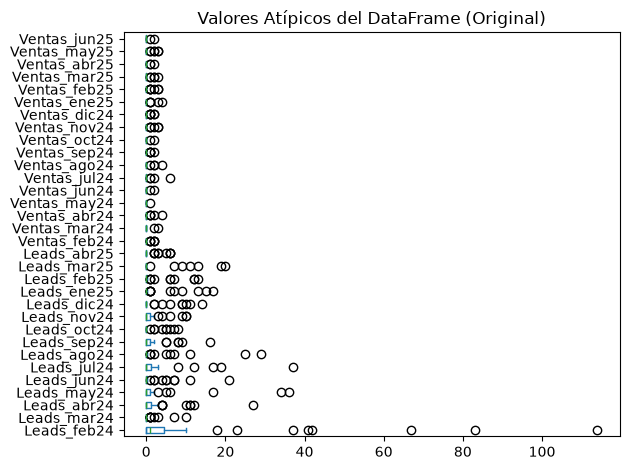

In [38]:
fig = plt.figure(figsize=(16, 12))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del DataFrame (Original)")
plt.tight_layout()
plt.show()


In [39]:
# --- Método elegido: percentiles 1% y 99% (no IQR) ---
# Se calculan los percentiles 1% y 99% de todas las columnas cuantitativas
# y se usan como límites inferior y superior.
p1 = cuantitativas.quantile(0.01)
p99 = cuantitativas.quantile(0.99)

print("\n--- Usando percentiles 1% y 99% ---")
print("Percentil 1%:\n", p1)
print("\nPercentil 99%:\n", p99)


--- Usando percentiles 1% y 99% ---
Percentil 1%:
 Leads_feb24     0.0
Leads_mar24     0.0
Leads_abr24     0.0
Leads_may24     0.0
Leads_jun24     0.0
Leads_jul24     0.0
Leads_ago24     0.0
Leads_sep24     0.0
Leads_oct24     0.0
Leads_nov24     0.0
Leads_dic24     0.0
Leads_ene25     0.0
Leads_feb25     0.0
Leads_mar25     0.0
Leads_abr25     0.0
Ventas_feb24    0.0
Ventas_mar24    0.0
Ventas_abr24    0.0
Ventas_may24    0.0
Ventas_jun24    0.0
Ventas_jul24    0.0
Ventas_ago24    0.0
Ventas_sep24    0.0
Ventas_oct24    0.0
Ventas_nov24    0.0
Ventas_dic24    0.0
Ventas_ene25    0.0
Ventas_feb25    0.0
Ventas_mar25    0.0
Ventas_abr25    0.0
Ventas_may25    0.0
Ventas_jun25    0.0
Name: 0.01, dtype: float64

Percentil 99%:
 Leads_feb24     101.91
Leads_mar24       8.83
Leads_abr24      21.15
Leads_may24      35.22
Leads_jun24      17.10
Leads_jul24      29.98
Leads_ago24      27.44
Leads_sep24      13.27
Leads_oct24       7.61
Leads_nov24      10.00
Leads_dic24      12.83
Leads_ene25

In [40]:
# Filtrar: se mantienen los valores entre p1 y p99
data_percentiles = cuantitativas[(cuantitativas >= p1) & (cuantitativas <= p99)]
valores_nulos = data_percentiles.isnull().sum()
print("Nulos tras aplicar percentiles:\n", valores_nulos)

Nulos tras aplicar percentiles:
 Leads_feb24     1
Leads_mar24     1
Leads_abr24     1
Leads_may24     1
Leads_jun24     1
Leads_jul24     1
Leads_ago24     1
Leads_sep24     1
Leads_oct24     1
Leads_nov24     0
Leads_dic24     1
Leads_ene25     1
Leads_feb25     1
Leads_mar25     1
Leads_abr25     0
Ventas_feb24    0
Ventas_mar24    1
Ventas_abr24    1
Ventas_may24    1
Ventas_jun24    1
Ventas_jul24    1
Ventas_ago24    1
Ventas_sep24    1
Ventas_oct24    1
Ventas_nov24    0
Ventas_dic24    0
Ventas_ene25    1
Ventas_feb25    0
Ventas_mar25    1
Ventas_abr25    1
Ventas_may25    0
Ventas_jun25    1
dtype: int64


In [ ]:
# Reemplazar los outliers (NaN) por la mediana de cada columna
data_clean_percentiles = data_percentiles.copy()
data_clean_percentiles = data_clean_percentiles.fillna(round(data_percentiles.median(), 2))
valores_nulos = data_clean_percentiles.isnull().sum()
print("Nulos tras reemplazo (percentiles):\n", valores_nulos)

Nulos tras reemplazo (percentiles):
 Leads_feb24     0
Leads_mar24     0
Leads_abr24     0
Leads_may24     0
Leads_jun24     0
Leads_jul24     0
Leads_ago24     0
Leads_sep24     0
Leads_oct24     0
Leads_nov24     0
Leads_dic24     0
Leads_ene25     0
Leads_feb25     0
Leads_mar25     0
Leads_abr25     0
Ventas_feb24    0
Ventas_mar24    0
Ventas_abr24    0
Ventas_may24    0
Ventas_jun24    0
Ventas_jul24    0
Ventas_ago24    0
Ventas_sep24    0
Ventas_oct24    0
Ventas_nov24    0
Ventas_dic24    0
Ventas_ene25    0
Ventas_feb25    0
Ventas_mar25    0
Ventas_abr25    0
Ventas_may25    0
Ventas_jun25    0
dtype: int64


<Figure size 1600x1200 with 0 Axes>

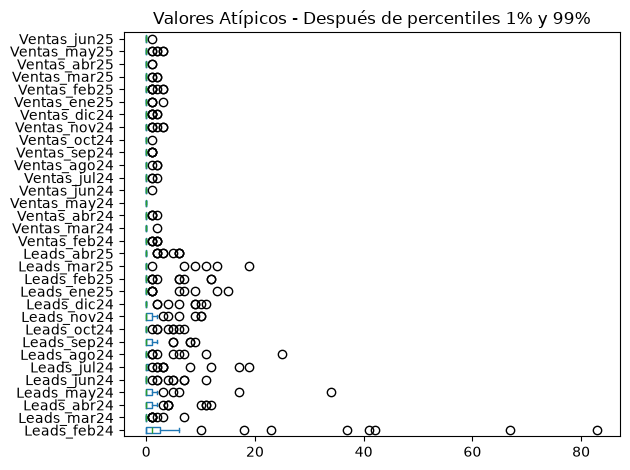

In [43]:
fig = plt.figure(figsize=(16, 12))
data_clean_percentiles.plot(kind='box', vert=False)
plt.title("Valores Atípicos - Después de percentiles 1% y 99%")
plt.tight_layout()
plt.show()


In [44]:
# Unión y exportación
Datos_limpios = pd.concat([cualitativas, data_clean_percentiles], axis=1)
Datos_limpios.head()
valores_nulos = Datos_limpios.isnull().sum()
print("Nulos finales:\n", valores_nulos)

Nulos finales:
 Asesor          0
Leads_feb24     0
Leads_mar24     0
Leads_abr24     0
Leads_may24     0
Leads_jun24     0
Leads_jul24     0
Leads_ago24     0
Leads_sep24     0
Leads_oct24     0
Leads_nov24     0
Leads_dic24     0
Leads_ene25     0
Leads_feb25     0
Leads_mar25     0
Leads_abr25     0
Ventas_feb24    0
Ventas_mar24    0
Ventas_abr24    0
Ventas_may24    0
Ventas_jun24    0
Ventas_jul24    0
Ventas_ago24    0
Ventas_sep24    0
Ventas_oct24    0
Ventas_nov24    0
Ventas_dic24    0
Ventas_ene25    0
Ventas_feb25    0
Ventas_mar25    0
Ventas_abr25    0
Ventas_may25    0
Ventas_jun25    0
dtype: int64


In [45]:
Datos_limpios.to_csv("Analisisdepiso_sin_outliers.csv", index=False)
